## 🧩 Imports

In [16]:
import json
import pandas as pd
import numpy as np
import random
import joblib
from sklearn.ensemble import IsolationForest
from sklearn.preprocessing import StandardScaler
from sklearn.decomposition import PCA
import matplotlib.pyplot as plt
import seaborn as sns

## 📊 Generate Dataset

Each sample includes:

- `src_port`: randomly selected from common service ports.
- `dst_port`: a random high port number.
- `packet_size`: typical packet sizes.
- `duration_ms`: duration of the communication.
- `protocol`: randomly selected between TCP and UDP.

This data is saved to `training_data.json` for future use.

In [24]:
COMMON_PORTS = [80, 443, 22, 8080]

def generate_normal_data():
    return {
        "src_port": random.choice(COMMON_PORTS),
        "dst_port": random.randint(1024, 65535),
        "packet_size": random.randint(100, 1500),
        "duration_ms": random.randint(50, 500),
        "protocol": random.choice(["TCP", "UDP"])
    }

dataset = [generate_normal_data() for _ in range(1000)]

with open("../dataset/training_data.json", "w") as f:
    json.dump(dataset, f, indent=2)


In [25]:
with open("F:/python/SE_project/anomaly-detection-project-hani/dataset/training_data.json") as f:
    raw_data = json.load(f)

df = pd.DataFrame(raw_data)
display(df)

,src_port,dst_port,packet_size,duration_ms,protocol
0,443,21492,799,84,UDP
1,443,28397,632,419,UDP
2,8080,10039,475,249,UDP
3,443,1287,705,311,TCP
4,80,39264,426,232,TCP
...,...,...,...,...,...
995,80,46851,1208,412,TCP
996,80,55302,949,253,TCP
997,8080,20301,604,464,UDP
998,443,7682,142,92,TCP


### 🧼 Preprocessing Function

In [26]:
def preprocess_data(df):
    df_encoded = pd.get_dummies(df, columns=['protocol'], drop_first=True)
    
    numerical_cols = ['src_port', 'dst_port', 'packet_size', 'duration_ms']
    df_encoded[numerical_cols] = df_encoded[numerical_cols].astype(float)
    
    scaler = StandardScaler()
    df_encoded[numerical_cols] = scaler.fit_transform(df_encoded[numerical_cols])
    
    joblib.dump(scaler, "scaler.joblib")
    return df_encoded

processed_data = preprocess_data(df)

### 🤖 Train Isolation Forest

- `n_estimators=100`: number of trees in the forest.
- `contamination=0.01`: assumes 1% of the data is anomalous.
- `random_state=42`: ensures reproducibility.


In [ ]:
model = IsolationForest(n_estimators=100, contamination=0.1, random_state=42)
model.fit(processed_data)

,n_estimators,100
,max_samples,'auto'
,contamination,0.1
,max_features,1.0
,bootstrap,False
,n_jobs,None
,random_state,42
,verbose,0
,warm_start,False


### 💾 Save Trained Model

In [32]:
joblib.dump(model, "anomaly_model.joblib")

['anomaly_model.joblib']

# predict data

In [33]:
scores = model.score_samples(processed_data) 
predictions = model.predict(processed_data)
print(predictions)

[ 1  1  1  1  1  1  1  1 -1  1  1  1  1 -1  1  1  1  1  1 -1  1  1 -1  1
  1  1  1  1  1  1  1  1  1 -1  1  1  1  1  1 -1  1  1 -1  1 -1  1  1  1
  1  1  1  1  1  1  1  1  1  1  1 -1  1  1  1  1  1  1  1 -1 -1  1  1  1
  1  1  1  1 -1  1  1  1  1  1  1  1  1 -1  1  1  1  1  1  1 -1  1 -1  1
  1  1  1  1  1  1  1  1  1  1  1  1  1  1 -1 -1 -1  1  1  1  1  1  1  1
  1  1  1  1  1  1  1  1  1  1  1  1  1  1  1  1  1  1  1  1 -1  1  1  1
  1  1  1  1  1  1  1  1  1  1  1  1  1  1  1  1  1  1  1  1  1  1  1 -1
  1  1  1  1  1  1  1  1  1  1  1 -1  1  1  1  1  1  1  1  1  1  1  1  1
  1  1  1 -1  1  1  1  1  1  1  1  1  1  1  1  1  1  1  1  1  1  1  1  1
  1  1  1  1  1  1  1  1  1 -1  1  1  1  1 -1  1 -1  1  1  1  1  1  1  1
  1  1  1  1  1  1  1  1  1  1 -1  1 -1  1  1  1  1  1  1  1  1  1  1  1
  1  1  1  1  1  1  1  1  1  1  1  1  1  1 -1 -1  1  1  1  1  1  1  1  1
  1  1  1  1  1  1  1  1  1  1  1  1  1  1  1  1  1  1  1  1  1  1  1  1
  1 -1 -1  1  1  1  1  1  1  1 -1  1  1  1  1  1  1

## Evaluation and Visualization of Anomaly Detection Results

Number of anomalies detected: 100


,src_port,dst_port,packet_size,duration_ms,protocol,prediction,confidence_score
8,443,62394,1475,70,UDP,-1,0.594515
13,8080,57573,1446,356,TCP,-1,0.614680
19,8080,12470,237,177,UDP,-1,0.585418
22,8080,30934,936,50,UDP,-1,0.582560
33,8080,57835,403,317,TCP,-1,0.587970


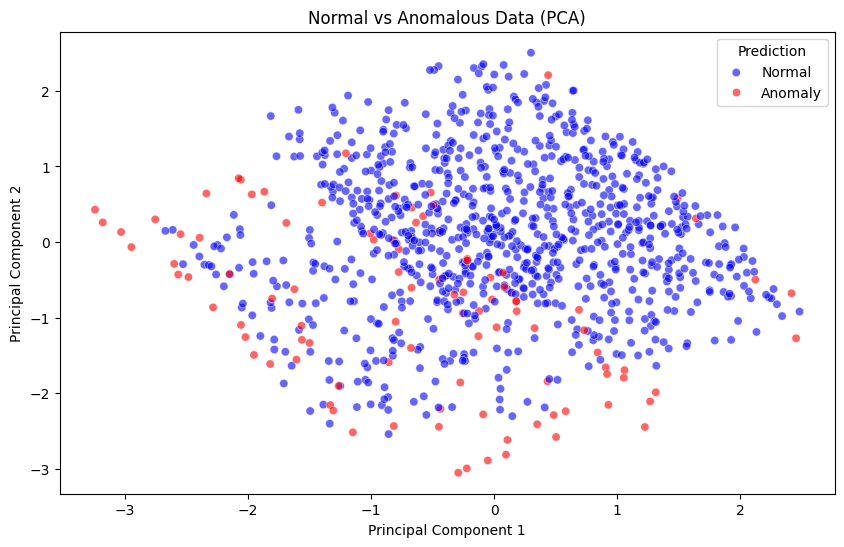

Explained variance ratio by PCA: [0.25915018 0.24827441]


In [34]:
df['prediction'] = predictions
df['confidence_score'] = -scores  

anomalies = df[df['prediction'] == -1]
anomalies.to_csv("anomalies_detected.csv", index=False)
print(f"Number of anomalies detected: {len(anomalies)}")
display(anomalies.head())


pca = PCA(n_components=2)
pca_data = pca.fit_transform(processed_data)

pca_df = pd.DataFrame(data=pca_data, columns=['PC1', 'PC2'])
pca_df['prediction'] = predictions

plt.figure(figsize=(10, 6))
sns.scatterplot(data=pca_df, x='PC1', y='PC2', hue='prediction', palette={1: 'blue', -1: 'red'}, alpha=0.6)
plt.title('Normal vs Anomalous Data (PCA)')
plt.xlabel('Principal Component 1')
plt.ylabel('Principal Component 2')
plt.legend(title='Prediction', labels=['Normal', 'Anomaly'])
plt.show()

print(f"Explained variance ratio by PCA: {pca.explained_variance_ratio_}")